In [ ]:
import numpy as np
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import PowerNorm
from scipy.stats import chi2
import matplotlib.pyplot as plt


In [3]:
def read_room_office():
    repo_root = Path.cwd().parent  # because you run from src/
    data_dir = repo_root / "data"

    df_room = pd.read_pickle(data_dir / "room" / "df_3k_7k_room.pkl")
    df_office = pd.read_pickle(data_dir / "office" / "df_3k_7k_office.pkl")
    return df_room, df_office

df_room, df_office = read_room_office()

In [4]:
import pandas as pd

def split_los_nlos(df_room, df_office, size):
    """
    Split Room and Office DataFrames into LOS and NLOS subsets.

    Parameters
    ----------
    df_room : dict
        Dictionary containing room DataFrames, e.g.:
        {"3k": df_room_3k, "7k": df_room_7k}
    df_office : dict
        Dictionary containing office DataFrames, e.g.:
        {"3k": df_office_3k, "7k": df_office_7k}
    size : str
        Either "3k" or "7k"

    Returns
    -------
    dict
        {
            "room": {"LOS": df_LOS_room, "NLOS": df_NLOS_room},
            "office": {"LOS": df_LOS_office, "NLOS": df_NLOS_office}
        }
    """
    out = {}

    for env_name, df_dict in [("room", df_room), ("office", df_office)]:
        df = df_dict[size]
        s = df["experiment_setup"].astype(str)

        df_los = df[
            s.str.contains("LOS", case=False, na=False) &
            ~s.str.contains("NLOS", case=False, na=False)
        ].copy()

        df_nlos = df[
            s.str.contains("NLOS", case=False, na=False)
        ].copy()

        out[env_name] = {"LOS": df_los, "NLOS": df_nlos}

    return out

split_3k = split_los_nlos(df_room, df_office, "3k")
split_7k = split_los_nlos(df_room, df_office, "7k")

In [24]:
def make_xy_arrays(split_dict, feature_col="iq_64abs"):
    """
    Convert split DataFrames into NumPy feature arrays.

    Parameters
    ----------
    split_dict : dict
        Output of split_los_nlos(...), e.g.
        {
            "room": {"LOS": df1, "NLOS": df2},
            "office": {"LOS": df3, "NLOS": df4}
        }
    feature_col : str
        Column containing the 64 IQ-absolute values as a sequence per row.

    Returns
    -------
    dict
        {
            "X_room_LOS": np.ndarray,
            "X_room_NLOS": np.ndarray,
            "X_office_LOS": np.ndarray,
            "X_office_NLOS": np.ndarray
        }
    """
    out = {}

    for env in ["room", "office"]:
        for cls in ["LOS", "NLOS"]:
            df = split_dict[env][cls]

            # each row contains a sequence of length 64
            X = np.vstack(df[feature_col].to_numpy())

            out[f"X_{env}_{cls}"] = X

    return out

arrays_3k = make_xy_arrays(split_3k, feature_col="iq_64abs")
X_room_3k_LOS   = arrays_3k["X_room_LOS"]
X_room_3k_NLOS  = arrays_3k["X_room_NLOS"]
X_office_3k_LOS = arrays_3k["X_office_LOS"]
X_office_3k_NLOS = arrays_3k["X_office_NLOS"]

In [5]:
def make_y_arrays(split_dict):
    """
    Create label arrays from split DataFrames.

    LOS  -> -1
    NLOS -> +1

    Parameters
    ----------
    split_dict : dict
        Output of split_los_nlos(...), e.g.
        {
            "room": {"LOS": df1, "NLOS": df2},
            "office": {"LOS": df3, "NLOS": df4}
        }

    Returns
    -------
    dict
        {
            "y_room_LOS": np.ndarray,
            "y_room_NLOS": np.ndarray,
            "y_office_LOS": np.ndarray,
            "y_office_NLOS": np.ndarray
        }
    """
    out = {}

    for env in ["room", "office"]:
        for cls in ["LOS", "NLOS"]:
            df = split_dict[env][cls]
            label = -1 if cls == "LOS" else +1
            y = np.full(len(df), label, dtype=int)
            out[f"y_{env}_{cls}"] = y

    return out

labels_3k = make_y_arrays(split_3k)

In [6]:
def make_train_test_data(split_dict, feature_col="iq_abs64", test_size=0.30, seed=2584):
    """
    Build train/test sets for room and office from split LOS/NLOS DataFrames.

    Parameters
    ----------
    split_dict : dict
        Output of split_los_nlos(...), e.g.
        {
            "room": {"LOS": df1, "NLOS": df2},
            "office": {"LOS": df3, "NLOS": df4}
        }
    feature_col : str
        Column containing the IQ-absolute sequence (length 64).
    test_size : float
        Fraction used for testing, e.g. 0.30.
    seed : int
        Random seed.

    Returns
    -------
    dict
        {
            "Xtr_room", "Xte_room", "Ytr_room", "Yte_room",
            "Xtr_office", "Xte_office", "Ytr_office", "Yte_office"
        }
    """
    out = {}
    for env in ["room", "office"]:
        df_los = split_dict[env]["LOS"]
        df_nlos = split_dict[env]["NLOS"]

        X_los = np.vstack(df_los[feature_col].to_numpy())
        X_nlos = np.vstack(df_nlos[feature_col].to_numpy())

        y_los = -np.ones(len(df_los), dtype=int)
        y_nlos = +np.ones(len(df_nlos), dtype=int)

        X = np.vstack([X_los, X_nlos])
        y = np.concatenate([y_los, y_nlos])

        Xtr, Xte, Ytr, Yte = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )

        out[f"Xtr_{env}"] = Xtr
        out[f"Xte_{env}"] = Xte
        out[f"Ytr_{env}"] = Ytr
        out[f"Yte_{env}"] = Yte

    return out

data_3k = make_train_test_data(split_3k, feature_col="iq_64abs", test_size=0.30, seed=2584)

[[-2.37103511e+00  2.13065986e+00 -5.08436678e-02 ...  1.87761641e+00
  -9.99238140e-01  2.40160448e+00]
 [-2.54579256e+00 -8.02720895e-01 -1.61192085e-01 ...  3.01936927e-01
  -2.24912011e-01 -5.94437390e-02]
 [-2.84445675e-01  3.61605265e+00 -2.90315993e+00 ... -1.77767579e-01
   4.02967828e-01 -2.08285461e+00]
 ...
 [-4.95164622e+00  7.01204911e-01  1.07254689e+00 ...  1.10109477e-03
   1.36043324e+00  8.54110723e-01]
 [-1.22905677e+00 -2.96791882e+00 -9.96490729e-03 ... -3.79962123e-01
  -1.35815289e+00 -8.60769622e-02]
 [-2.69499546e+00  2.77485949e+00  2.12062500e+00 ...  6.62301095e-01
   1.00595593e-01  1.24381366e+00]] [[-3.13856771  0.9788378  -0.64207135 ...  0.27022454 -0.7159669
  -0.6818008 ]
 [-2.999859   -1.62711822  0.47190211 ... -0.36999897  0.54275752
   0.58726178]
 [-4.88864593 -0.81136699  0.93512452 ... -1.63640108  0.24486596
   0.04796141]
 ...
 [ 1.73139827  1.00645072  3.17427835 ...  1.0472167   0.13631865
  -2.66113462]
 [-2.41945366 -1.89309192 -0.3358813

ValueError: x, y, and format string must not be None

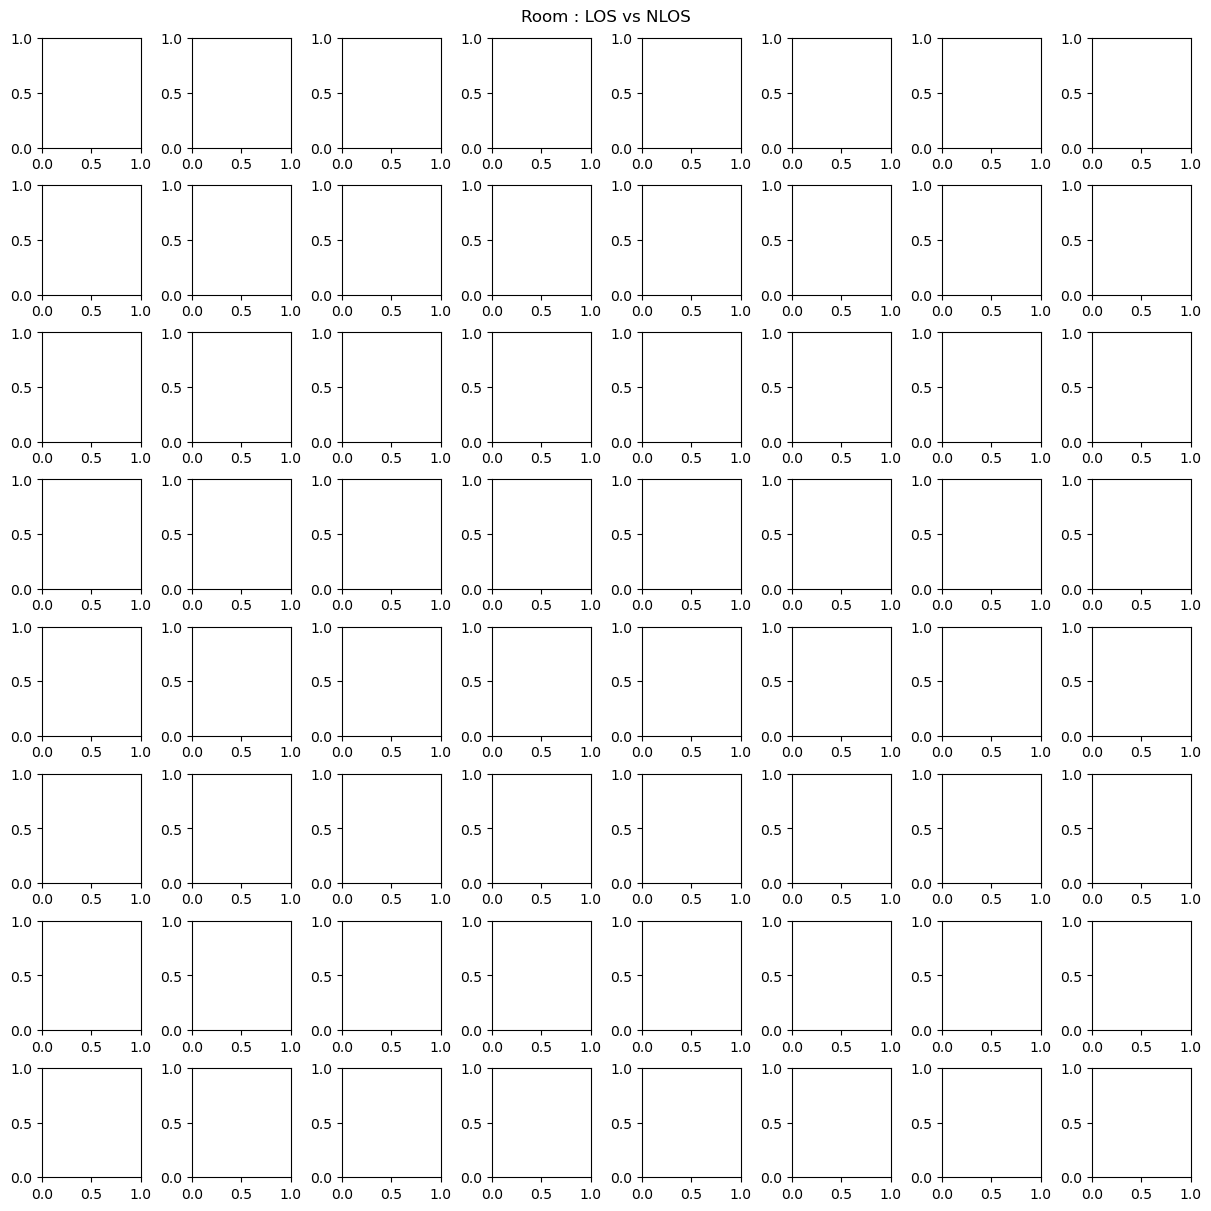

In [ ]:
CFG = dict(
    n_components=8,
    random_state=0,

    # hexbin
    gridsize=15,
    mincnt=10,
    alpha_hex_los=0.7,
    alpha_hex_nlos=0.7,
    gamma_norm=0.5,

    # dense-core / dispersion metrics
    q_area=0.95,          # used for area computation + ratio text
    q_ellipse=0.95,       # used for ellipse drawing

    # marginals
    ci=0.95,              # central interval ticks on marginals (set 0.95 for 95%)
    frac_marg=0.22,
    alpha_marg_los=0.5,
    alpha_marg_nlos=0.5,
    tick_frac=0.12,

    # annotation
    ratio_mode="nlos_over_los",   # "nlos_over_los" or "los_over_nlos"
    ratio_fmt="{:.2f}",
)
def conf_ellipse_area_2d(X, q=0.80):
    """
    Area of the 2D confidence ellipse containing probability mass q
    under a Gaussian model with robust (trimmed) covariance.
    """
    _, S = _robust_center_cov_2d(X, keep=q)
    r2 = chi2.ppf(q, df=2)            # chi-square radius^2
    return float(np.pi * r2 * np.sqrt(np.linalg.det(S)))

def _robust_center_cov_2d(X, keep=0.80):
    """
    Robustly estimate (mu, Sigma) by keeping only the central keep-fraction
    according to Mahalanobis distance (iterative trimming, 1 pass).
    X: (N,2)
    """
    mu = X.mean(axis=0)
    S  = np.cov(X, rowvar=False) + 1e-9*np.eye(2)
    Sinv = np.linalg.inv(S)
    d2 = np.einsum("ni,ij,nj->n", X-mu, Sinv, X-mu)  # squared Mahalanobis
    thr = np.quantile(d2, keep)
    Xc = X[d2 <= thr]
    mu = Xc.mean(axis=0)
    S  = np.cov(Xc, rowvar=False) + 1e-9*np.eye(2)
    return mu, S

def kde_gaussian_fixed(x, grid, bw):
    x = np.asarray(x, float)
    grid = np.asarray(grid, float)
    u = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * u**2).mean(axis=1) / (bw * np.sqrt(2*np.pi))

def adaptive_kde_abramson(x, grid, alpha=0.5, eps=1e-12):
    x = np.asarray(x, float)
    if x.size > 5000:
        x = x[np.random.default_rng(0).choice(x.size, size=5000, replace=False)]
    grid = np.asarray(grid, float)
    n = x.size
    s = x.std(ddof=1)
    if n < 2 or s == 0:
        bw = 1e-3 if s == 0 else 1.06*s*n**(-1/5)
        return kde_gaussian_fixed(x, grid, bw)
    
def pairplot_with_bdistance_hexbin(
    X, y, title=None,
    n_components=None, random_state=None,
    gridsize=None, mincnt=None,
    q_area=None, q_ellipse=None,
    ci=None, frac_marg=None,
    alpha_hex_los=None, alpha_hex_nlos=None,
    alpha_marg_los=None, alpha_marg_nlos=None,
    tick_frac=None, gamma_norm=None,
    ratio_mode=None, ratio_fmt=None,
):
    # -------- defaults from CFG --------
    n_components   = CFG["n_components"]   if n_components   is None else n_components
    random_state   = CFG["random_state"]   if random_state   is None else random_state
    gridsize       = CFG["gridsize"]       if gridsize       is None else gridsize
    mincnt         = CFG["mincnt"]         if mincnt         is None else mincnt
    q_area         = CFG["q_area"]         if q_area         is None else q_area
    q_ellipse      = CFG["q_ellipse"]      if q_ellipse      is None else q_ellipse
    ci             = CFG["ci"]             if ci             is None else ci
    frac_marg      = CFG["frac_marg"]      if frac_marg      is None else frac_marg
    alpha_hex_los  = CFG["alpha_hex_los"]  if alpha_hex_los  is None else alpha_hex_los
    alpha_hex_nlos = CFG["alpha_hex_nlos"] if alpha_hex_nlos is None else alpha_hex_nlos
    alpha_marg_los = CFG["alpha_marg_los"] if alpha_marg_los is None else alpha_marg_los
    alpha_marg_nlos= CFG["alpha_marg_nlos"]if alpha_marg_nlos is None else alpha_marg_nlos
    tick_frac      = CFG["tick_frac"]      if tick_frac      is None else tick_frac
    gamma_norm     = CFG["gamma_norm"]     if gamma_norm     is None else gamma_norm
    ratio_mode     = CFG["ratio_mode"]     if ratio_mode     is None else ratio_mode
    ratio_fmt      = CFG["ratio_fmt"]      if ratio_fmt      is None else ratio_fmt

    
    # -------- PCA (separately for LOS and NLOS, as in your original) --------
    Z1 = _pca8(X_los,  n_components=n_components, random_state=random_state)
    Z2 = _pca8(X_nlos, n_components=n_components, random_state=random_state)

    df_los  = pd.DataFrame(Z1, columns=[f"PC{i+1}" for i in range(n_components)])
    df_nlos = pd.DataFrame(Z2, columns=[f"PC{i+1}" for i in range(n_components)])

    X1 = df_los.to_numpy()
    X2 = df_nlos.to_numpy()
    print(X1, X2)
    cols = df_los.columns
    k = df_los.shape[1]

    # -------- precompute ellipse areas for ALL (i,j) --------
    los_area  = {}
    nlos_area = {}
    for i in range(k):
        for j in range(k):
            Xpair_los  = np.c_[X1[:, j], X1[:, i]]
            Xpair_nlos = np.c_[X2[:, j], X2[:, i]]
            los_area[(i, j)]  = conf_ellipse_area_2d(Xpair_los,  q=q_area)
            nlos_area[(i, j)] = conf_ellipse_area_2d(Xpair_nlos, q=q_area)

    # -------- plot grid --------
    fig, axes = plt.subplots(k, k, figsize=(12, 12), constrained_layout=True)
    fig.suptitle(title)

    for i in range(k):
        for j in range(k):
            ax = axes[i, j]

            if i == j:
                xg = np.linspace(
                    min(X1[:, i].min(), X2[:, i].min()),
                    max(X1[:, i].max(), X2[:, i].max()),
                    400
                )
                y1 = adaptive_kde_abramson(X1[:, i], xg, alpha=0.5)
                y2 = adaptive_kde_abramson(X2[:, i], xg, alpha=0.5)
                ax.plot(xg, y1, label="LOS")
                ax.plot(xg, y2, label="NLOS")
                add_marginals(ax, X1[:, i], X1[:, i], bins="auto", frac=frac_marg, alpha=alpha_marg_los,
                              ci=ci, tick_frac=tick_frac, color="blue", mode='top')
                add_marginals(ax, X2[:, i], X2[:, i], bins="auto", frac=frac_marg, alpha=alpha_marg_los,
                              ci=ci, tick_frac=tick_frac, color="orange", mode='top')
                #ax.set_yticks([])
            

            elif j < i:
                # ----- LOS lower triangle -----
                x = X1[:, j]; y = X1[:, i]
                ax.hexbin(
                    x, y, gridsize=gridsize,
                    reduce_C_function=reduce_kurtosis,
                    mincnt=mincnt, alpha=alpha_hex_los,
                    cmap="Blues", norm=PowerNorm(gamma=gamma_norm)
                )
                add_marginals(ax, x, y, bins="auto", frac=frac_marg, alpha=alpha_marg_los,
                              ci=ci, tick_frac=tick_frac, color="blue")
                _add_conf_ellipse(ax, np.c_[x, y], q=q_ellipse, edgecolor="tab:blue", lw=2)

                aL = los_area[(i, j)]
                aN = nlos_area[(i, j)]
                ratio = (aN / aL) if ratio_mode == "nlos_over_los" else (aL / aN)
                ax.text(0.02, 1.01, f"A-ratio={ratio_fmt.format(ratio)}",
                        transform=ax.transAxes, va="bottom", fontsize=13)

            else:
                # ----- NLOS upper triangle -----
                x = X2[:, j]; y = X2[:, i]
                ax.hexbin(
                    x, y, gridsize=gridsize,
                    reduce_C_function=reduce_kurtosis,
                    mincnt=mincnt, alpha=alpha_hex_nlos,
                    cmap="Oranges", norm=PowerNorm(gamma=gamma_norm)
                )
                add_marginals(ax, x, y, bins="auto", frac=frac_marg, alpha=alpha_marg_nlos,
                              ci=ci, tick_frac=tick_frac, color="orange")
                _add_conf_ellipse(ax, np.c_[x, y], q=q_ellipse, edgecolor="tab:orange", lw=2)

# show tick numbers on: TOP row + BOTTOM row, and LEFT column
# (hide them everywhere else)

            # # ----- x ticks -----
            # if i == 0:
            #     ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
            #     ax.xaxis.set_ticks_position("top")
            #     ax.xaxis.set_label_position("top")
            #     ax.set_xlabel(cols[j])  # optional: show labels on top row
            if i == k - 1:
                ax.tick_params(axis="x", bottom=True, labelbottom=True, top=False, labeltop=False, labelsize=18)
                ax.xaxis.set_ticks_position("bottom")
                ax.xaxis.set_label_position("bottom")
                ax.set_xlabel(cols[j], fontsize=22)
            else:
                ax.set_xticks([])
                ax.tick_params(axis="x", top=False, bottom=False, labeltop=False, labelbottom=False, labelsize=18)

            # ----- y ticks -----
            if j == 0:
                ax.tick_params(axis="y", left=True, labelleft=True, right=False, labelright=False, labelsize=18)
                ax.set_ylabel(cols[i], fontsize=22)
            else:
                ax.set_yticks([])
                ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False, labelsize=18)
            
            if (i==0) and (j==0): 
                ax.tick_params(axis="y", left=True, labelleft=True, right=False, labelright=False, labelsize=18)
                ax.set_ylabel(cols[j], fontsize=22)


    # legends
    leg_classes = fig.legend(
        handles=[Patch(facecolor="tab:blue"), Patch(facecolor="tab:orange")],
        labels=["LOS", "NLOS"], ncols=2,
        loc="upper right", bbox_to_anchor=(0.4, 1.04), frameon=True, fontsize=18
    )
    leg_kurt = fig.legend(
        handles=[Line2D([0], [0], color="black", lw=0)],
        labels=[r"metrics: kurtosis + AKDE + marginals + ellipse"],
        loc="upper right", bbox_to_anchor=(1.03, 1.04), frameon=True, fontsize=18
    )
    fig.add_artist(leg_classes)
    fig.add_artist(leg_kurt)
    plt.show()
    return None

pairplot_with_bdistance_hexbin(
    X_room_3k_LOS,
    X_room_3k_NLOS,
    title=f"Room : LOS vs NLOS",
    gridsize=10,
    mincnt=200,
    q_area=0.95,
    q_ellipse=0.95,
    ci=0.95,
)

In [31]:

def plot_all_graphs_from_split(
    split_dict,
    feature_col="iq_abs64",
    size_tag="3k",
    gridsize=10,
    mincnt_room=200,
    mincnt_office=20,
    q_area=0.95,
    q_ellipse=0.95,
    ci=0.95,
):
    """
    Build LOS/NLOS NumPy arrays from a split dictionary and plot
    Room and Office graphs.

    Parameters
    ----------
    split_dict : dict
        Output of split_los_nlos(...), e.g. split_3k or split_7k
        {
            "room": {"LOS": df_los_room, "NLOS": df_nlos_room},
            "office": {"LOS": df_los_office, "NLOS": df_nlos_office}
        }
    feature_col : str
        Column containing the IQ sequence per row, e.g. "iq_abs64"
    size_tag : str
        Title tag, e.g. "3k" or "7k"
    gridsize, mincnt_room, mincnt_office, q_area, q_ellipse, ci :
        Parameters forwarded to pairplot_with_bdistance_hexbin

    Returns
    -------
    dict
        {
            "X_LOS_room": ...,
            "X_NLOS_room": ...,
            "X_LOS_office": ...,
            "X_NLOS_office": ...
        }
    """

    def _to_array(df):
        return np.vstack(df[feature_col].to_numpy())

    # ---------------------------------------------------------
    # Make arrays
    # ---------------------------------------------------------
    X_LOS_room   = _to_array(split_dict["room"]["LOS"])
    X_NLOS_room  = _to_array(split_dict["room"]["NLOS"])
    X_LOS_office = _to_array(split_dict["office"]["LOS"])
    X_NLOS_office = _to_array(split_dict["office"]["NLOS"])

    # ---------------------------------------------------------
    # Plot Room
    # ---------------------------------------------------------
    pairplot_with_bdistance_hexbin(
        X_LOS_room,
        X_NLOS_room,
        title=f"Room {size_tag}: LOS vs NLOS",
        gridsize=gridsize,
        mincnt=mincnt_room,
        q_area=q_area,
        q_ellipse=q_ellipse,
        ci=ci,
    )

    # ---------------------------------------------------------
    # Plot Office
    # ---------------------------------------------------------
    pairplot_with_bdistance_hexbin(
        X_LOS_office,
        X_NLOS_office,
        title=f"Office {size_tag}: LOS vs NLOS",
        gridsize=gridsize,
        mincnt=mincnt_office,
        q_area=q_area,
        q_ellipse=q_ellipse,
        ci=ci,
    )

    return {
        "X_LOS_room": X_LOS_room,
        "X_NLOS_room": X_NLOS_room,
        "X_LOS_office": X_LOS_office,
        "X_NLOS_office": X_NLOS_office,
    }

In [30]:
X_room_3k_LOS

array([[188.60540819, 149.69301921, 243.46046907, ..., 104.95713411,
         60.20797289, 113.86395391],
       [192.00260415, 129.63024338, 170.4699387 , ...,  99.24716621,
         62.00806399, 113.21660656],
       [151.20846537, 256.00781238, 261.84155514, ..., 243.52617929,
        229.71286425, 165.60495162],
       ...,
       [173.36666346,  77.47257579, 173.11845656, ...,  72.44998275,
         31.04834939,  44.91102315],
       [163.37992533,  82.73451517,  85.0940656 , ..., 113.84638773,
        276.00724628, 278.70593822],
       [197.68662069,  75.66372975, 191.0942176 , ...,  85.95929269,
         47.16990566, 149.33519344]])